In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import bernoulli
from scipy.stats import rv_discrete


## Visualization functions for later use below

In [2]:
def plot_histogram(sample, theoretical_min=None, theoretical_max=None, title="Histogram"):
    if not theoretical_min:
        theoretical_min = np.min(sample)
    if not theoretical_max:
        theoretical_max = np.max(sample)

    bins = np.arange(theoretical_min, theoretical_max + 2) - 0.5
    sum_counts, bin_edges, _ = plt.hist(sample,
                                        range=(theoretical_min - 0.5, theoretical_max + 1 + 0.5),
                                        bins=bins,
                                        rwidth=.5)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    plt.xticks(bin_centers, [int(x) for x in bin_centers])
    plt.grid()

    plt.xlabel('value')
    plt.ylabel('number of occurences')
    plt.title(title)

    plt.show()


## Coins

In [3]:
# coin

def throw_coin_with_numpy_random(n_throws: int) -> np.ndarray:
    # assumes it is a fair coin where each side is equally likely to come up
    n_sides = 2
    sample = np.random.randint(1, n_sides + 1, size=n_throws, dtype=int)
    # print(f"type(sample)={type(sample)}")
    # print(f"sample={sample}")
    return sample

def throw_coin_with_scipy_bernoulli(p: float, n_throws: int) -> np.ndarray:
    # a coin could also be thought of as a die with only two sides
    if not (0.0 <= p and p <= 1.0):
        raise ValueError("Parameter p must be in [0, 1].")
    sample = bernoulli.rvs(p=p, size=n_throws)
    # print(f"type(sample)={type(sample)}")
    # print(f"sample={sample}")
    return sample


### Fair coin with NumPy only a few throws

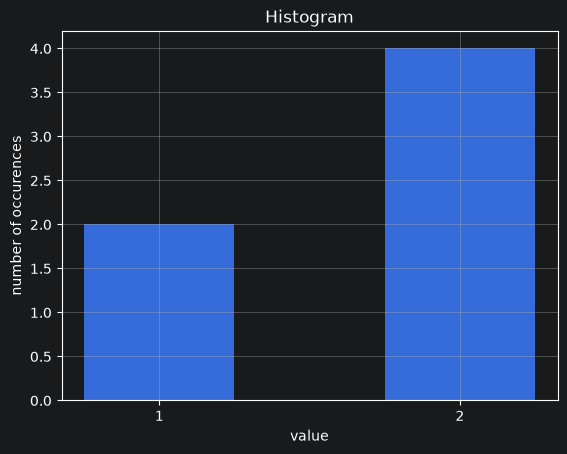

In [4]:
# fair coin with NumPy
plot_histogram(throw_coin_with_numpy_random(n_throws=6))

### Fair coin with SciPy 1000 throws

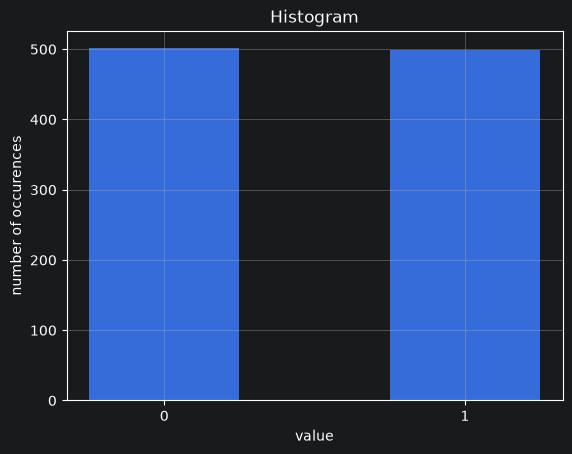

In [5]:
# fair coin with SciPy
plot_histogram(throw_coin_with_scipy_bernoulli(p=0.5, n_throws=1000))

### Unfair coin with SciPy 1000 throws

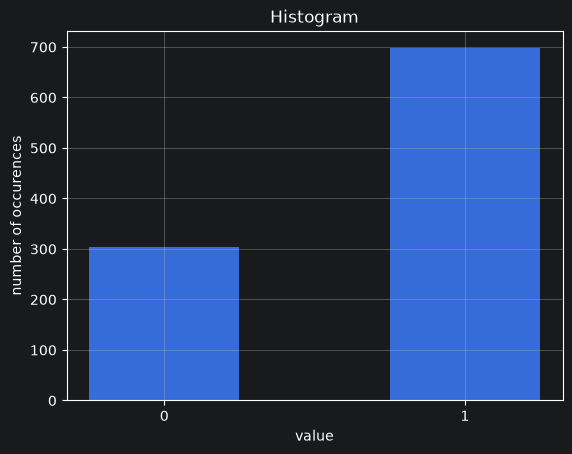

In [6]:
# unfair coin with SciPy
plot_histogram(throw_coin_with_scipy_bernoulli(p=0.7, n_throws=1000))

## Dice

In [7]:
# die

def throw_die_with_numpy_random(n_sides: int, n_throws: int) -> np.ndarray:
    # assumes it is a fair die where each side is equally likely to come up
    sample = np.random.randint(1, n_sides + 1, size=n_throws, dtype=int)
    print(f"type(sample)={type(sample)}")
    # print(f"sample={sample}")
    return sample

def throw_die_with_scipy_discrete(ps: list[float], n_throws: int) -> np.ndarray:
    # probabilities of the sides of the die to come up are given by ps
    if len(ps) < 1:
        raise ValueError("There must be at least one parameter value in ps.")
    for p in ps:
        if not (0.0 <= p and p <= 1.0):
            raise ValueError("Each parameter in ps must be in [0, 1].")
    if not np.isclose(np.sum(ps), 1.0):
        raise ValueError("The parameters in ps must sum to 1.")
    possible_values = range(1, len(ps) + 1)
    rv = rv_discrete(name='die', values=(possible_values, ps))
    sample = rv.rvs(size=n_throws)
    # print(f"type(sample)={type(sample)}")
    # print(f"sample={sample}")
    return sample


### Fair die with NumPy 1000 throws

type(sample)=<class 'numpy.ndarray'>


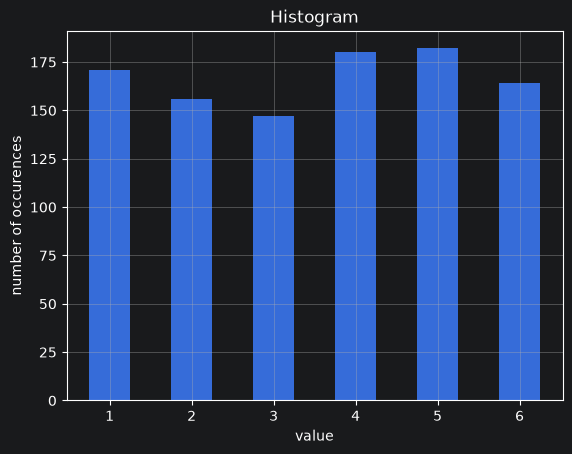

In [8]:
# fair die with NumPy
plot_histogram(throw_die_with_numpy_random(n_sides=6, n_throws=1000))

### Fair die with SciPy 10000 throws

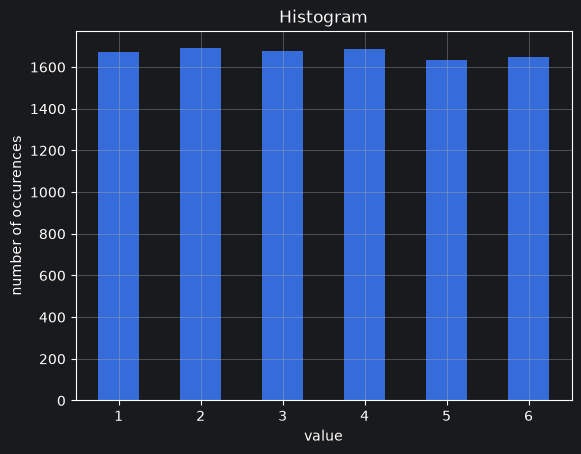

In [9]:
# fair die with SciPy
plot_histogram(throw_die_with_scipy_discrete(ps=[1/6, 1/6, 1/6, 1/6, 1/6, 1/6], n_throws=10000))

### Unfair die with SciPy 1000 throws

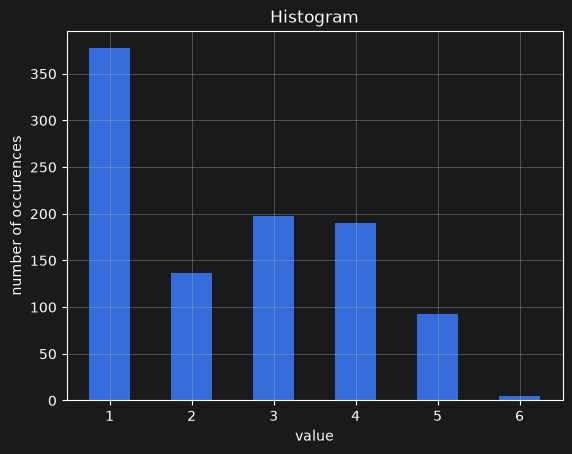

In [10]:
# unfair die with SciPy
plot_histogram(throw_die_with_scipy_discrete(ps=[0.35, 0.14, 0.20, 0.20, 0.1, 0.01], n_throws=1000))